Running adaptive backward euler solver...

Steps taken: 1920
Final y(2.0) = -3.161462
Steady state sqrt(10) = 3.162278
Time elapsed: 0.0096 s


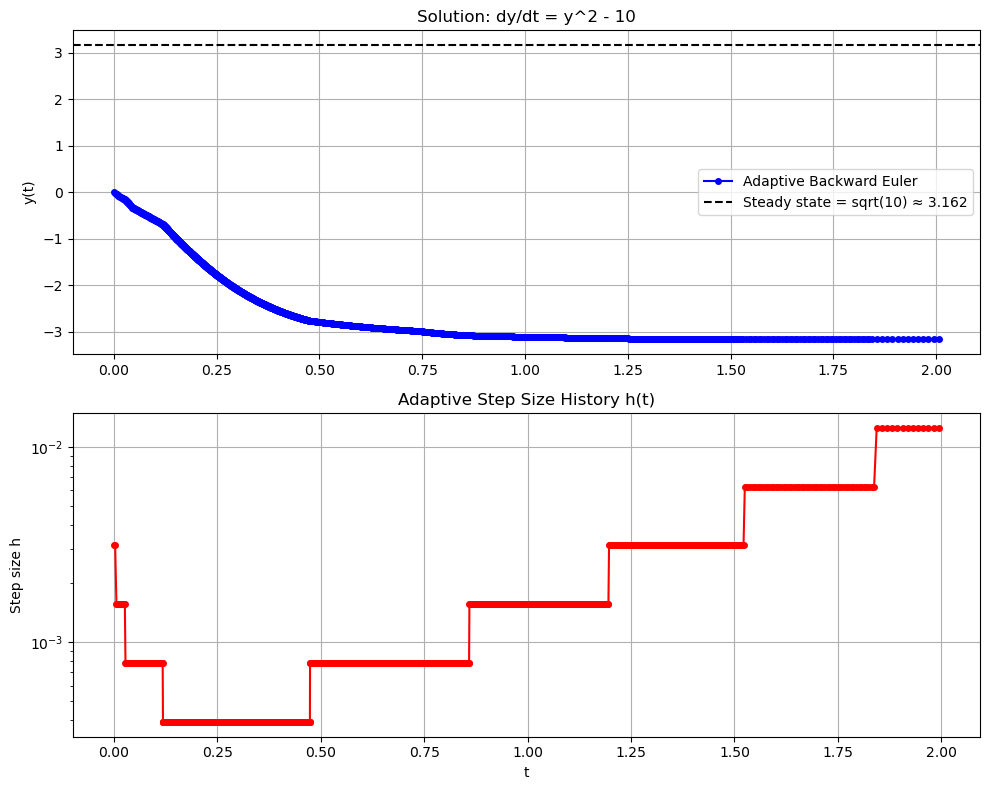

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import time

import numpy as np
import matplotlib.pyplot as plt
import time

def f(t, y):
    return y**2 - 10

def fprime(y):
    return 2 * y

y0 = 0.0
t0 = 0.0
tf = 2.0


def backward_euler_step(f, y, t, h, tol=1e-6, max_iter=50):
    y_next = y  # initial guess
    for _ in range(max_iter):
        g_val = y_next - y - h * f(t + h, y_next)
        g_prime_val = 1 - h * fprime(y_next)
        if abs(g_prime_val) < tol:  # avoid division by zero
            break
        y_new = y_next - g_val / g_prime_val
        if abs(y_new - y_next) < tol:
            return y_new  # converged
        y_next = y_new
    return y_next


def backward_euler_adaptive(f, y0, t0, tf, h_init, tol=1e-6, max_iter=50):
    t_values = [t0]
    y_values = [y0]
    h = h_init
    t = t0
    y = y0

    while t < tf:
        if t + h > tf:  
            h = tf - t

        y_full = backward_euler_step(f, y, t, h, tol, max_iter)

        h_half = h / 2
        y_half_1 = backward_euler_step(f, y, t, h_half, tol, max_iter)
        y_half_2 = backward_euler_step(f, y_half_1, t + h_half, h_half, tol, max_iter)

    
        error = abs(y_full - y_half_2)

        if error > tol:
            h /= 2 
            continue  
        elif error < tol / 2:
            h *= 2 

        t += h
        y = y_half_2
        t_values.append(t)
        y_values.append(y)

    return np.array(t_values, dtype=float), np.array(y_values, dtype=float)

# ============================================================
# RUN AND PLOT
# ============================================================

h_init = 0.1
tol = 1e-6

print("Running adaptive backward euler solver...")
start = time.time()
t_vals, y_vals = backward_euler_adaptive(f, y0, t0, tf, h_init, tol)
elapsed = time.time() - start

print(f"\nSteps taken: {len(t_vals) - 1}")
print(f"Final y({tf}) = {y_vals[-1]:.6f}")
print(f"Steady state sqrt(10) = {np.sqrt(10):.6f}")
print(f"Time elapsed: {elapsed:.4f} s")

# plot 1 - solution
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(t_vals, y_vals, 'b-o', markersize=4, label='Adaptive Backward Euler')
axes[0].axhline(y=np.sqrt(10), color='k', linestyle='--',
                label=f'Steady state = sqrt(10) ≈ {np.sqrt(10):.3f}')
axes[0].set_ylabel('y(t)')
axes[0].set_title('Solution: dy/dt = y^2 - 10')
axes[0].legend()
axes[0].grid(True)

# plot 2 - step sizes
step_sizes = np.diff(t_vals)
axes[1].semilogy(t_vals[:-1], step_sizes, 'r-o', markersize=4)
axes[1].set_ylabel('Step size h')
axes[1].set_xlabel('t')
axes[1].set_title('Adaptive Step Size History h(t)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

having done part 3 of the final project already its interesting to see how this approach was much more easier to understand than the way the code was presented in the assignment. seeing if else statements reminds me of coe 301, but I figured it was meant to be easier to understand so that we can build off of it and build more adaptive implicit solver. 